<a href="https://colab.research.google.com/github/retired-snail0345/cap-comp215/blob/main/Project_1_Lakshay_100183743_COMP215.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project 1: Watts-Strogatz Graphs**
Replicating the Watts and Strogatz Experiment

**Course:** COMP 215  
**Author:** Lakshay Bhutani
**Date:** March 2026  


## Purpose
This notebook reproduces the famous experiment by Watts and Strogatz (1998).  
They discovered that **small-world networks** can arise from regular ring lattice graphs  
by randomly rewiring a small fraction of edges.

The experiment shows that as the rewiring probability `p` increases:
- The average "shortest path length" drops quickly.
- The clustering coefficient decreases much more slowly.

This creates a "sweet spot" where the network has both short paths like random graphs.

## Imports

- `networkx` — to build and analyze graphs
- `numpy` — for the `logspace` function
- `matplotlib` — to plot results
- `random` — to generate random numbers for rewiring

In [2]:
import networkx as nx #to build and analyze graphs
import numpy as np #for the logspace function
import matplotlib.pyplot as plt #to plot results
import random #to generate random numbers

##Simpulation Paramters

Edit the values in the cell below to customize the experiment.
--
`Parameters`

`N`: Number of nodes in the ring lattice graph

`K`: Each node connects to `K` nearest neighbors

`NUM_P_VALUES`: How many different `p` values to test (more = smoother plot, slower run)

`NUM_TRIALS`: How many random graphs to avg each "p" value (more = smoother results)

In [4]:
#Parameters can be edited to try different patterns

N = 20               #number of nodes in the ring lattice
K = 4                #each node connects to K nearest neighbours and it should be even
NUM_P_VALUES = 15    #number of p values to test between 0.001 and 1.0
NUM_TRIALS = 5       #number of random trials to get an avg for p value

## Step 1: Building a Ring Lattice


In [5]:
def make_ring_lattice(n, k):
    """
    Create a ring lattice graph with n nodes where each node
    is connected to its k nearest neighbors.

    Parameters
    n: number of nodes
    k: number of neighbours per node and it must be even

    Return
    G: networkx.Graph
    """
    G = nx.Graph()

    #add all nodes numbered 0 to n-1
    for node in range(n):
        G.add_node(node)

    #connect each node to its k/2 neighbours on each side
    #we use modulo (%) to wrap around the ring
    half_k = k // 2
    for node in range(n):
        for offset in range(1, half_k + 1):
            neighbour = (node + offset) % n
            G.add_edge(node, neighbour)

    return G

In [6]:
#test: builds a ring lattice
test_graph = make_ring_lattice(10, 4)
print("Nodes:", test_graph.number_of_nodes())
print("Edges:", test_graph.number_of_edges())
print("Neighbours of node 0:", list(test_graph.neighbors(0)))

Nodes: 10
Edges: 20
Neighbours of node 0: [1, 2, 8, 9]


## Step 2: Rewiring Edges

"Rewiring" means:
1. Pick an existing edge (u, v).
2. With probability `p`, disconnect it and reconnect `u` to a **random** node instead.
3. Make sure we don't create a self-loop or a duplicate edge.

In [7]:
def rewire(G, p):
    """
    rewire each edge in graph G with probability p
    this modifies the graph in place

    Parameters
    G: networkx.Graph, the graph to rewire
    p: float, probability of rewiring each edge (between 0 and 1)
    """
    #get a list of all nodes for picking random targets
    nodes = list(G.nodes())

    #make a copy of the edge list
    edges = list(G.edges())

    for u, v in edges:
        #flip a coin, rewiere the edge with P(p) (probbality )
        if random.random() < p:
            # pick a random new target for u
            new_target = random.choice(nodes)

            #we make sure we don't create a self-loop or duplicate edge
            #keep picking until we find a valid target
            while new_target == u or G.has_edge(u, new_target):
                new_target = random.choice(nodes)

            G.remove_edge(u, v) #remove the old edge and add the new one
            G.add_edge(u, new_target)

In [8]:
#test
test_graph = make_ring_lattice(10, 4)
print("Before rewiring — edges:", test_graph.number_of_edges())
rewire(test_graph, 0.5)
print("After rewiring  — edges:", test_graph.number_of_edges())
print("(Edge count stays the same — we just moved them around)")

Before rewiring — edges: 20
After rewiring  — edges: 20
(Edge count stays the same — we just moved them around)


## Step 3: Measuring Clustering and Path Length

We need two measurements for each graph:

1. **Average Clustering Coefficient (C)**:
  It measures how much nodes tend to form tightly connected groups.

2. **Average Shortest Path Length (L)**: the avg number of "hops" it takes to get from any node to any other node.

In [10]:
def average_clustering(G):
    """
    compute the average clustering coefficient of graph G
    Returns
    float, the average clustering coefficient
    """
    return nx.average_clustering(G)

In [11]:
def average_path_length(G):
    """
    calculates the avg shortest path of graph G
    work only if there is a path between every pair of nodes in the graph

    returns
    float, the average shortest path
    """
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        #if the graph got disconnected by rewiring,
        #return infinity as that means the path does not exsit
        return float('inf')

In [16]:
#test
test_graph = make_ring_lattice(10, 4)
print("clustering coefficient:", round(average_clustering(test_graph), 4))
print("average path length:", round(average_path_length(test_graph), 4))

clustering coefficient: 0.5
average path length: 1.6667


## Step 4: Running the Experiment

The experiment works as follows:

1. Pick `p` values between 0.001 to 1.0 using `logspace`.
2. For each `p` value:

   2.1 Run `NUM_TRIALS` trials

   2.2  In each trial, build a new ring lattice, rewire it with P(`p`)
     and then measure the clustering coefficient and average path length

   2.3  Average the results across all trials
3. Normalize the results by dividing by the values at `p = 0` which is the original ring lattice.

The normalization means:
- `C(p) / C(0)` = 1.0 at `p = 0`, then decreases.
- `L(p) / L(0)` = 1.0 at `p = 0`, then decreases.

In [17]:
# measure C and L for p=0
original = make_ring_lattice(N, K)
C0 = average_clustering(original)
L0 = average_path_length(original)

print("Ring lattice with N =", N, "and K =", K)
print("C(0) =", round(C0, 4))
print("L(0) =", round(L0, 4))

Ring lattice with N = 20 and K = 4
C(0) = 0.5
L(0) = 2.8947


In [18]:
#generate the p values using logspace
#logspace(-3, 0, n) gives n values from 10^-3 = 0.001 to 10^0 = 1.0
p_values = np.logspace(-3, 0, NUM_P_VALUES)

print("p values we will test:")
for p in p_values:
    print(f"  p = {p:.4f}")

p values we will test:
  p = 0.0010
  p = 0.0016
  p = 0.0027
  p = 0.0044
  p = 0.0072
  p = 0.0118
  p = 0.0193
  p = 0.0316
  p = 0.0518
  p = 0.0848
  p = 0.1389
  p = 0.2276
  p = 0.3728
  p = 0.6105
  p = 1.0000


## Step 5: Run the Experiment

In [20]:
#these lists will store the normalized results for each p
C_normalized = []    # C(p) / C(0)
L_normalized = []    # L(p) / L(0)

print("Running experiment...")
print(f"Testing {NUM_P_VALUES} p-values with {NUM_TRIALS} trials each.")
print()

for p in p_values: #lists to collect results from each trial at this p
    C_trials = []
    L_trials = []

    for trial in range(NUM_TRIALS):
        G = make_ring_lattice(N, K) #build a new ring lattice

        #rewire it with P(p)
        rewire(G, p)

        #measure clustering and path length
        C_trials.append(average_clustering(G))
        L_trials.append(average_path_length(G))

    #find the average in all trials for this p
    C_avg = sum(C_trials) / len(C_trials)
    L_avg = sum(L_trials) / len(L_trials)

    #normalize by dividing by the p=0 values
    C_normalized.append(C_avg / C0)
    L_normalized.append(L_avg / L0)

    print(f"  p = {p:.4f}  ->  C(p)/C(0) = {C_avg/C0:.4f},  L(p)/L(0) = {L_avg/L0:.4f}")

print()

Running experiment...
Testing 15 p-values with 5 trials each.

  p = 0.0010  ->  C(p)/C(0) = 1.0000,  L(p)/L(0) = 1.0000
  p = 0.0016  ->  C(p)/C(0) = 1.0000,  L(p)/L(0) = 1.0000
  p = 0.0027  ->  C(p)/C(0) = 0.9793,  L(p)/L(0) = 0.9825
  p = 0.0044  ->  C(p)/C(0) = 0.9927,  L(p)/L(0) = 0.9887
  p = 0.0072  ->  C(p)/C(0) = 0.9780,  L(p)/L(0) = 0.9618
  p = 0.0118  ->  C(p)/C(0) = 1.0000,  L(p)/L(0) = 1.0000
  p = 0.0193  ->  C(p)/C(0) = 0.9467,  L(p)/L(0) = 0.9575
  p = 0.0316  ->  C(p)/C(0) = 0.9153,  L(p)/L(0) = 0.9291
  p = 0.0518  ->  C(p)/C(0) = 0.9480,  L(p)/L(0) = 0.9520
  p = 0.0848  ->  C(p)/C(0) = 0.7840,  L(p)/L(0) = 0.8716
  p = 0.1389  ->  C(p)/C(0) = 0.7049,  L(p)/L(0) = 0.8225
  p = 0.2276  ->  C(p)/C(0) = 0.6113,  L(p)/L(0) = 0.7993
  p = 0.3728  ->  C(p)/C(0) = 0.4024,  L(p)/L(0) = 0.7458
  p = 0.6105  ->  C(p)/C(0) = 0.3802,  L(p)/L(0) = 0.7433
  p = 1.0000  ->  C(p)/C(0) = 0.2557,  L(p)/L(0) = 0.7425



##Step 6: Plotting the Graph
We plot both C(p)/C(0) and L(p)/L(0) on the same graph



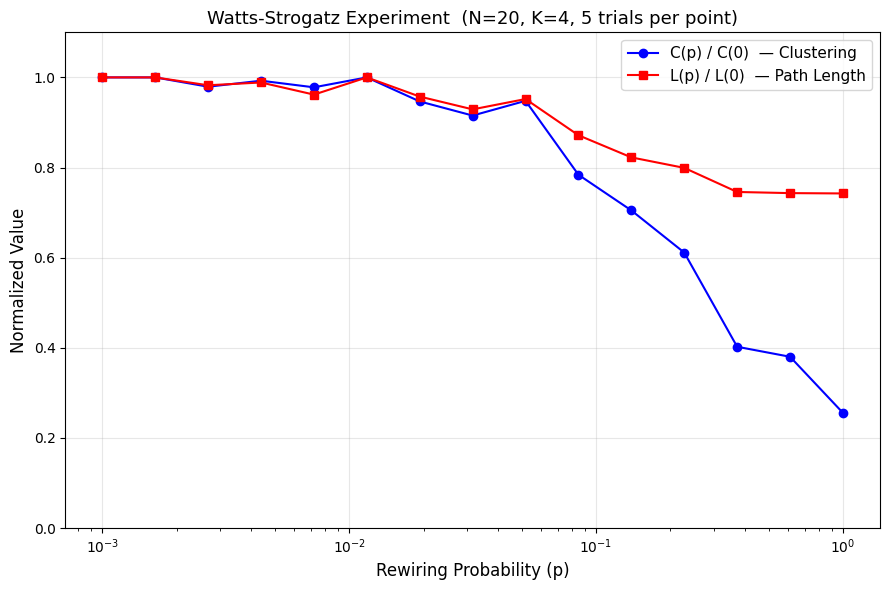

In [21]:
plt.figure(figsize=(9, 6))

#plot both curves
plt.plot(p_values, C_normalized, 'bo-', label='C(p) / C(0)  — Clustering')
plt.plot(p_values, L_normalized, 'rs-', label='L(p) / L(0)  — Path Length')

#use a log x-axis so we can see the small p values
plt.xscale('log')

#labels and title
plt.xlabel('Rewiring Probability (p)', fontsize=12)
plt.ylabel('Normalized Value', fontsize=12)
plt.title(f'Watts-Strogatz Experiment  (N={N}, K={K}, {NUM_TRIALS} trials per point)',
          fontsize=13)

#add a legend and grid
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

#setting axis limits
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

1. **What Python built-in is logspace most similar to?**  
   `range()`, both generate a sequence of values between a start and an end point.  
   But `range` uses equal adding progression, while `logspace` uses multiplicative  
   steps (powers of 10).

2. **Why use logspace for the p values?**  
   Using logspace for p-values is primarily done to handle extremely small probabilities

3. **Why does path length drop fast but clustering drops slowly?**  
   